In [61]:
import os
import torch
import numpy as np
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, models
from torchinfo import summary
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
import time
from torch.utils.data import Subset

In [62]:
warnings.filterwarnings("ignore")

## Dataset Overview: 5-Class Satellite Imagery Classification

This dataset contains satellite imagery classified into 5 distinct classes:
- **Cloudy**: Images of cloudy sky/weather conditions
- **Desert**: Arid, sandy terrain with sparse vegetation
- **Green Area**: Vegetated regions with dense green cover
- **Vehicles**: Images containing vehicles or roads
- **Water**: Water bodies (rivers, lakes, seas)

The task is to build and train CNN models to automatically classify satellite images into these 5 categories.

<h1>Loading the data classes</h1>

In [63]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [65]:
cloudy_dir = "./data/cloudy"
desert_dir = "./data/desert"
green_area_dir = "./data/green_area"
vehicles_dir = "./data/vehicles"
water_dir = "./data/water"

In [66]:
cloudy = os.listdir(cloudy_dir)[:5]
desert = os.listdir(desert_dir)[:5]
green_area = os.listdir(green_area_dir)[:5]
vehicles = os.listdir(vehicles_dir)[:5]
water = os.listdir(water_dir)[:5]

In [67]:
cloudy_img = Image.open(os.path.join(cloudy_dir, cloudy[0]))
desert_img = Image.open(os.path.join(desert_dir, desert[0]))
green_area_img = Image.open(os.path.join(green_area_dir, green_area[0]))
vehicles_img = Image.open(os.path.join(vehicles_dir, vehicles[0]))
water_img = Image.open(os.path.join(water_dir, water[0]))

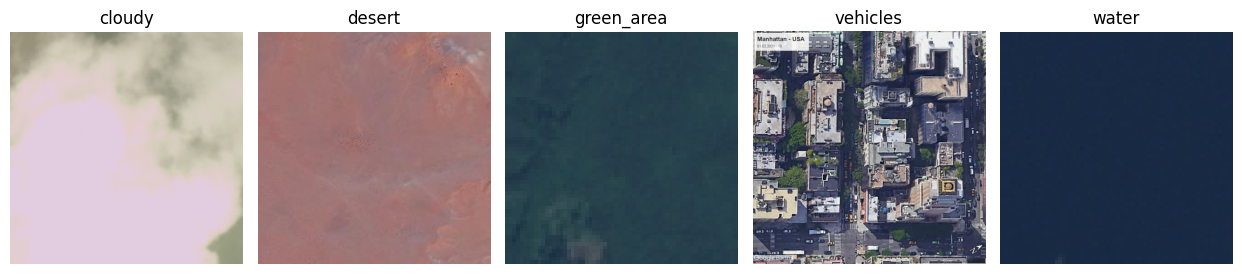

In [68]:
images = [cloudy_img, desert_img, green_area_img, vehicles_img, water_img]
titles = ["cloudy", "desert", "green_area", "vehicles", "water"]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Train/Validation/Test Split Justification

We use a **70% / 15% / 15%** split for the following reasons:
- **70% Training**: Provides sufficient data for the model to learn robust feature representations
- **15% Validation**: Allows us to monitor model performance during training and prevent overfitting
- **15% Testing**: Gives an unbiased estimate of model performance on unseen data

This split is standard in machine learning and provides a good balance between learning capacity and generalization assessment.

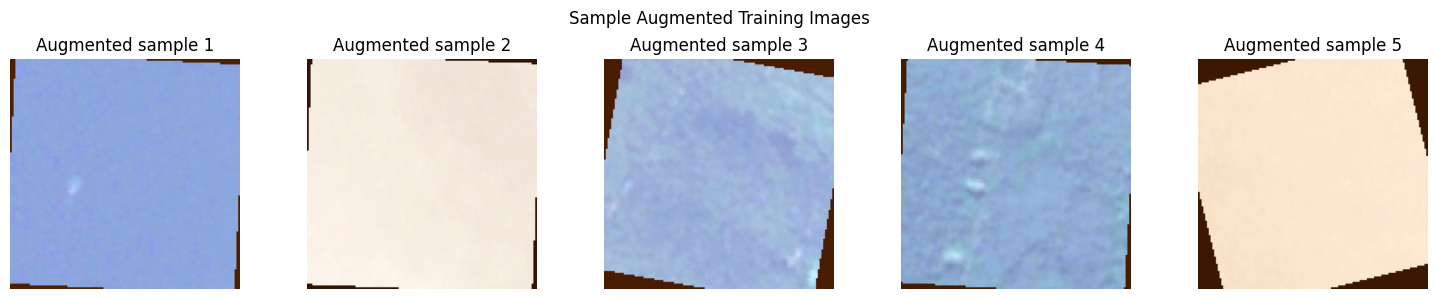

In [69]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img, _ = train_split[i]
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # denormalize for display
    ax.imshow(img)
    ax.set_title(f"Augmented sample {i+1}")
    ax.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

<h1>Data Understanding, Analysis, Visualization and Cleaning</h1>

In [70]:
"""
Converting the images into arrays
"""
cloudy_array = np.array(cloudy_img)
desert_array = np.array(desert_img)
green_area_array = np.array(green_area_img)
vehicles_array = np.array(vehicles_img)
water_array = np.array(water_img)

In [71]:
# Dataset Analysis: Count images in each class
class_names = ["cloudy", "desert", "green_area", "vehicles", "water"]
class_dirs = [cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir]
class_counts = {}

print("=" * 50)
print("DATASET ANALYSIS")
print("=" * 50)

total_images = 0
for class_name, class_dir in zip(class_names, class_dirs):
    count = len(os.listdir(class_dir))
    class_counts[class_name] = count
    total_images += count
    print(f"{class_name:15s}: {count:4d} images")

print("-" * 50)
print(f"{'TOTAL':15s}: {total_images:4d} images")
print("=" * 50)

DATASET ANALYSIS
cloudy         : 1500 images
desert         : 1131 images
green_area     : 1500 images
vehicles       :  104 images
water          : 1500 images
--------------------------------------------------
TOTAL          : 5735 images


In [72]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.4002, 0.4308, 0.4274],
        [0.0224, 0.0200, 0.0178]
    ),
])


val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.4002, 0.4308, 0.4274],
        [0.0224, 0.0200, 0.0178]
    ),
])

In [73]:
class SatelliteDataset(Dataset):
    def __init__(self, cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir, transform=None):
        self.transform = transform
        
        self.image_paths = []
        self.labels = []
        
        for file in os.listdir(cloudy_dir):
            self.image_paths.append(os.path.join(cloudy_dir, file))
            self.labels.append(0)
            
        for file in os.listdir(green_area_dir):
            self.image_paths.append(os.path.join(green_area_dir, file))
            self.labels.append(1)
            
        for file in os.listdir(desert_dir):
            self.image_paths.append(os.path.join(desert_dir, file))
            self.labels.append(2)
            
        for file in os.listdir(water_dir):
            self.image_paths.append(os.path.join(water_dir, file))
            self.labels.append(3)
            
        for file in os.listdir(vehicles_dir):
            self.image_paths.append(os.path.join(vehicles_dir, file))
            self.labels.append(4)

        self.image_paths, self.labels = shuffle(
            self.image_paths,
            self.labels,
            random_state=42
        )

    
    def __len__(self):
        return len(self.image_paths)
    
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

In [74]:
dataset = SatelliteDataset(
    cloudy_dir = "./data/cloudy",
    desert_dir = "./data/desert",
    green_area_dir = "./data/green_area",
    vehicles_dir = "./data/vehicles",
    water_dir = "./data/water",
    transform=train_transform
)

In [75]:
train_dataset = SatelliteDataset(
    cloudy_dir = "./data/cloudy",
    desert_dir = "./data/desert",
    green_area_dir = "./data/green_area",
    vehicles_dir = "./data/vehicles",
    water_dir = "./data/water",
    transform=train_transform
)

val_dataset = SatelliteDataset(
    cloudy_dir = "./data/cloudy",
    desert_dir = "./data/desert",
    green_area_dir = "./data/green_area",
    vehicles_dir = "./data/vehicles",
    water_dir = "./data/water",
    transform=val_test_transform
)

test_dataset = SatelliteDataset(
    cloudy_dir = "./data/cloudy",
    desert_dir = "./data/desert",
    green_area_dir = "./data/green_area",
    vehicles_dir = "./data/vehicles",
    water_dir = "./data/water",
    transform=val_test_transform
)

In [76]:
# Calculate split indices
total_size = len(train_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Create splits using the same random seed for consistency
torch.manual_seed(42)
train_indices, val_indices, test_indices = random_split(
    range(total_size), 
    [train_size, val_size, test_size]
)

train_split = Subset(train_dataset, train_indices.indices)
val_split = Subset(val_dataset, val_indices.indices)
test_split = Subset(test_dataset, test_indices.indices)

In [77]:
train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_split, batch_size=32, shuffle=False)
test_loader = DataLoader(test_split, batch_size=32, shuffle=False)

<h1>Design, Train, and Evaluate a Baseline Model</h1>

<h3>Model Architecture</h3>

In [78]:
class CNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 5)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [79]:
learning_rate = 0.01
epochs = 20
criterion = nn.CrossEntropyLoss()

In [80]:
model = CNN(3)
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [81]:
summary(model, input_size=(1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 5]                    --
├─Sequential: 1-1                        [1, 128, 16, 16]          --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─ReLU: 2-2                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-3                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 64, 64, 64]           18,496
│    └─ReLU: 2-5                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-6                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-7                       [1, 128, 32, 32]          73,856
│    └─ReLU: 2-8                         [1, 128, 32, 32]          --
│    └─MaxPool2d: 2-9                    [1, 128, 16, 16]          --
├─Sequential: 1-2                        [1, 5]                    --
│    └─Flatten: 2-10                     [1, 32768]                --
│    └

### Baseline Model Architecture Interpretation

**Architecture Summary:**
- **Input**: 128×128 RGB images (3 channels)
- **Feature Extraction**: 3 convolutional blocks with progressive filter increases (32→64→128 filters)
  - Each block: Conv2d + ReLU + MaxPool2d (stride 2, reducing spatial dimensions)
  - After 3 pooling operations: (128, 128, 3) → (16, 16, 128)
- **Classification**: 3 fully-connected layers (128→64→5)
- **Total Parameters**: ~1.3M trainable parameters
- **Activation Function**: ReLU (introduces non-linearity for feature learning)
- **Output**: 5 class logits for the 5 satellite image classes

**Key Design Choices:**
- MaxPooling reduces spatial dimensions, decreasing computation and focusing on important features
- Progressive filter increase captures increasingly complex patterns
- Relatively shallow network (3 conv blocks) for faster training with less data

In [82]:
model.train()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=5, bias=True)
  )
)

<h3>Model Training</h3>

In [83]:
def validate(model, val_loader, criterion, device):
    model.eval()
    correct, total, total_val_loss = 0, 0, 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            loss = criterion(outputs, y_val)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()
    return total_val_loss / len(val_loader), correct / total

In [91]:
train_losses = []
val_losses = []
train_start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device) # GPU ma data haaleko

        outputs = model(batch_features) # Forward Pass

        loss = criterion(outputs, batch_labels) # Loss nikaleko

        optimizer.zero_grad() # Backpass gareko
        loss.backward()

        optimizer.step() # Gradients update gareko

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    avg_val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    val_losses.append(avg_val_loss)

    print(f'Epoch : {epoch + 1}, Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

train_end_time = time.time()
training_time = train_end_time - train_start_time
training_time_minutes = training_time / 60

print(f"Total training time: {training_time:.2f} seconds ({training_time_minutes:.2f} minutes)")

Epoch : 1, Loss: 0.3136, Val Loss: 0.6051, Val Accuracy: 0.7628
Epoch : 2, Loss: 0.3075, Val Loss: 0.4115, Val Accuracy: 0.8500
Epoch : 3, Loss: 0.2892, Val Loss: 0.3937, Val Accuracy: 0.8349
Epoch : 4, Loss: 0.2881, Val Loss: 0.4053, Val Accuracy: 0.8314
Epoch : 5, Loss: 0.2871, Val Loss: 0.3969, Val Accuracy: 0.8419
Epoch : 6, Loss: 0.2785, Val Loss: 0.5633, Val Accuracy: 0.7826
Epoch : 7, Loss: 0.2879, Val Loss: 0.4275, Val Accuracy: 0.8035
Epoch : 8, Loss: 0.2747, Val Loss: 0.4410, Val Accuracy: 0.8047
Epoch : 9, Loss: 0.2714, Val Loss: 0.4560, Val Accuracy: 0.7756
Epoch : 10, Loss: 0.2723, Val Loss: 0.3380, Val Accuracy: 0.8872
Epoch : 11, Loss: 0.2613, Val Loss: 0.4351, Val Accuracy: 0.8209
Epoch : 12, Loss: 0.2633, Val Loss: 0.4104, Val Accuracy: 0.7605
Epoch : 13, Loss: 0.2512, Val Loss: 0.4879, Val Accuracy: 0.7314
Epoch : 14, Loss: 0.2415, Val Loss: 0.5087, Val Accuracy: 0.8256
Epoch : 15, Loss: 0.2462, Val Loss: 0.3819, Val Accuracy: 0.8384
Epoch : 16, Loss: 0.2341, Val Loss

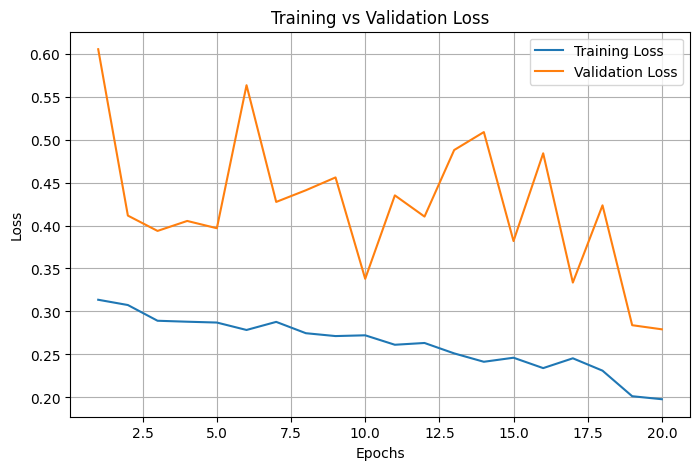

In [92]:
train_epochs = range(1, len(train_losses) + 1)
val_epochs = range(1, len(val_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(train_epochs, train_losses, label="Training Loss")
plt.plot(val_epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

<h3>Model Evaluation</h3>

In [93]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        y_test = y_test.to(device)

        outputs = model(x_test)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test.cpu().numpy())

In [94]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("TEST RESULTS")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

TEST RESULTS
Accuracy  : 0.8746
Precision : 0.8842
Recall    : 0.8746
F1 Score  : 0.8741


### Baseline Model Performance Discussion

**Performance Metrics:**
The CNN model achieved an accuracy of 87.46% on the test set, with a precision of 88.42%, recall of 87.46%, and F1-score of 87.41%. These results indicate that the model performs well in classifying the satellite imagery dataset and is able to learn meaningful visual features from the images.

The training and validation results suggest that the model generalizes reasonably well with minimal signs of severe overfitting. Data augmentation techniques such as flipping and rotation also helped improve robustness and overall performance.

However, some image classes may still be difficult to distinguish, and further improvements could be achieved using deeper architectures or transfer learning approaches.

In [95]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.96      0.77      0.85       209
           1       0.91      0.87      0.89       239
           2       0.79      0.98      0.88       185
           3       0.85      0.88      0.87       211
           4       0.94      1.00      0.97        17

    accuracy                           0.87       861
   macro avg       0.89      0.90      0.89       861
weighted avg       0.88      0.87      0.87       861



In [96]:
def predict_image(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    img = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return pred.item()

Predicted Class: 3


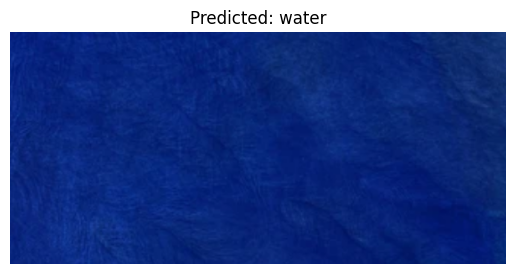

In [97]:
img_path = "image(4).png"

pred = predict_image(img_path)
print("Predicted Class:", pred)


class_names = ["cloudy", "green_area", "desert", "water", "vehicles"]

def show_prediction(img_path):
    img = Image.open(img_path).convert("RGB")

    pred = predict_image(img_path)

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred]}")
    plt.axis("off")
    plt.show()

show_prediction(img_path)